In [1]:
import torch
import numpy as np
import scipy.special as sc
from matplotlib import pyplot as plt
from matplotlib.ticker import ScalarFormatter,MaxNLocator,FuncFormatter
import matplotlib.gridspec as gridspec
import normflows as nf
from tqdm import tqdm

import sys
import os
c_directory = os.getcwd()
sys.path.append(os.path.dirname(c_directory))


import architecture
import SCD_simulator
from SCD_plot import SCD_plot

enable_cuda = True
CUDA_LAUNCH_BLOCKING=1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SCD_simulator.adjust_device(device)

seed=314159
torch.manual_seed(seed)

In [2]:

l10 = np.log(10)
vectorize_params = torch.ones(1024,2).to(device)

def log_likelihood(data,params,model):
    global vectorize_params
    if data.size !=  vectorize_params.size(0):
        vectorize_params = torch.ones((data.size(0),2),device=device)

    return model.log_prob(data,params*vectorize_params)

def log_post(data,params,model,lprior):
    return log_likelihood(data,params,model).sum() + lprior(params)


In [3]:
# Define flows
model_file = 'network.pt'
model = architecture.make_model(context_size=2,tail_bound=15)
model.load_state_dict(torch.load(model_file))

/tmp/ipykernel_483207/1302300593.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_file))


<All keys matched successfully>

In [4]:
# Define target
SCD_simulator.adjust_device(device)
target = SCD_simulator.target()

In [5]:
mu = torch.tensor((3,-1)).to(device)*l10
sig= torch.stack((target.lbeta_dist.scale,target.lsig_dist.scale))*l10

gts = mu + sig * torch.tensor((( 0, 0),
                               ( 1, 0),
                               ( 1,-1),
                               (-1, 1)),device = sig.device)

In [6]:

def make_plot(ax,th,model,target,first):
    #values = th.cpu().numpy()
    N=2**15
    x = target.sample(*th,N=N)[:,0]

    ax.set_title(
        fr'$\beta = 10^{{{round((th[0] / l10).item(), 2)}}}/\overline{{T}}$,  $\sigma= 10^{{{round((th[1] / l10).item(), 2)}}}$',fontsize=10
    )

    xx = torch.linspace(x.min()*.98,x.max()*1.02,201,device=th.device) 
    ly = model.log_prob(xx.reshape(-1,1), th.repeat(xx.size(0),1)).detach()
    x,xx,ly = x.cpu(),xx.cpu(),ly.cpu()
    


    ax.set_xlabel(r'$\log_{10}$ G',fontsize=15)
    ax.set_xlim(xx[0]/l10,xx[-1]/l10)
    if first:
        ax.plot(xx/l10,torch.exp(ly)*l10,label='NN likelihood')    
        ax.hist(x.reshape((1,-1))/l10,density=True,bins=25,label='Simulation',alpha=.8)
    else:
        ax.plot(xx/l10,torch.exp(ly)*l10)    
        ax.hist(x.reshape((1,-1))/l10,density=True,bins=25,alpha=.8)
    

In [7]:
def make_full_figure(model, target):
    fig = plt.figure(figsize=(8, 7))

    import matplotlib.gridspec as gridspec
    gs = gridspec.GridSpec(4, 4, height_ratios=[1, 0.001, 1, 1], hspace=0.6)  # NEW

    axs = np.empty((4,4), dtype=object)


    ### Row 0: Likelihood plots
    ths = gts
    for j in range(4):
        axs[0,j] = fig.add_subplot(gs[0,j])

    first = True
    for th, axi in zip(ths, axs[0]):
        make_plot(axi, th, model, target, first)
        first = False
    # Row 1: empty row → do not fill, no plots!

    ### Row 2: Posterior marginals beta
    mat = [['be{}'.format(i) for i in range(4)], ['bs{}'.format(i) for i in range(4)]]
    axmap = {}

    for j in range(4):
        axs[2,j] = fig.add_subplot(gs[2,j])  # posterior beta
        axmap[mat[0][j]] = axs[2,j]

    for j in range(4):
        axs[3,j] = fig.add_subplot(gs[3,j])  # posterior sigma
        axmap[mat[1][j]] = axs[3,j]


    Ndots = 50
    Ns = [512, 1024, 2048]

    first = True
    for (gt, be, bs) in zip(gts, mat[0], mat[1]):
        x = target.sample(*gt, N=max(Ns))
        x = x[:, 0].reshape(-1, 1)

        lbeta_range = gt[0] + target.lbeta_dist.scale * 0.05 * torch.linspace(-1, 1, 1+Ndots).to(device)
        lsig_range = gt[1] + target.lsig_dist.scale * 2.2 * torch.linspace(-1, 1, 1+Ndots).to(device)

        lb, ls = torch.meshgrid(lbeta_range, lsig_range, indexing='ij')
        dxlb = (lbeta_range[1] - lbeta_range[0]).item()
        dxls = (lsig_range[1] - lsig_range[0]).item()

        for N in Ns:
            th_post = torch.stack((lb.reshape(-1), ls.reshape(-1)), dim=1)
            arr = np.stack([log_post(x[:N], thi, model, target.log_prior).detach().cpu().numpy() for thi in th_post])

            ll = arr.reshape((lb.size(0), ls.size(0))) - arr.max()
            p = np.exp(ll)
            p = p / (p.sum() * (dxlb * dxls))


            axmap[bs].plot(lsig_range.cpu()/l10, p.sum(axis=0)*dxlb, label=f'{N} datapoints')

            axmap[bs].set_xlabel(r'$\log_{10}\sigma$', fontsize=15)
            axmap[bs].axvline(gt[-1].cpu()/l10, color='red')

            axmap[be].plot(lbeta_range.cpu()/l10, p.sum(axis=1)*dxls)
            axmap[be].set_xlabel(r'$\log_{10}\beta (\bar{T}^{-1})$', fontsize=15)
            axmap[be].axvline(gt[0].cpu()/l10, color='red')

        first = False

    for axi in np.array(axs[[2,3]]).reshape(-1):
        axi.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        axi.ticklabel_format(style='sci', axis='y', scilimits=(0, 0)) 

    for axi in np.array(axs[[2,3,0]]).reshape(-1):
        ymax = axi.get_ylim()[1]
        pow = np.floor(np.log10(ymax))
        ticks = np.arange(0, int(np.ceil(ymax)))
        

        if len(ticks) > 3:
            ticks = np.linspace(0, ticks[-1], 3)
            ticks = (ticks/(10**pow)).astype(int)*(10**pow)

        axi.set_yticks(ticks)

    fig.text(0.07, 0.80, 'Likelihood', va='center', rotation='vertical', fontsize=15)
    fig.text(0.07, 0.32, 'Posterior', va='center', rotation='vertical', fontsize=15)


    ### Legend 1: for likelihood (row 0)
    handles_lik, labels_lik = axs[0,0].get_legend_handles_labels()
    fig.legend(handles_lik, labels_lik, loc='upper center', bbox_to_anchor=(0.5, .96), ncol=3, frameon=False)

    ### Legend 2: for posterior (rows 1+2)
    handles_post, labels_post = axs[3,0].get_legend_handles_labels()
    fig.legend(handles_post, labels_post, loc='upper center', bbox_to_anchor=(0.5, 0.62), ncol=4, frameon=False)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig('panelbc.png', dpi=600)

    return fig

/tmp/ipykernel_483207/3625205712.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


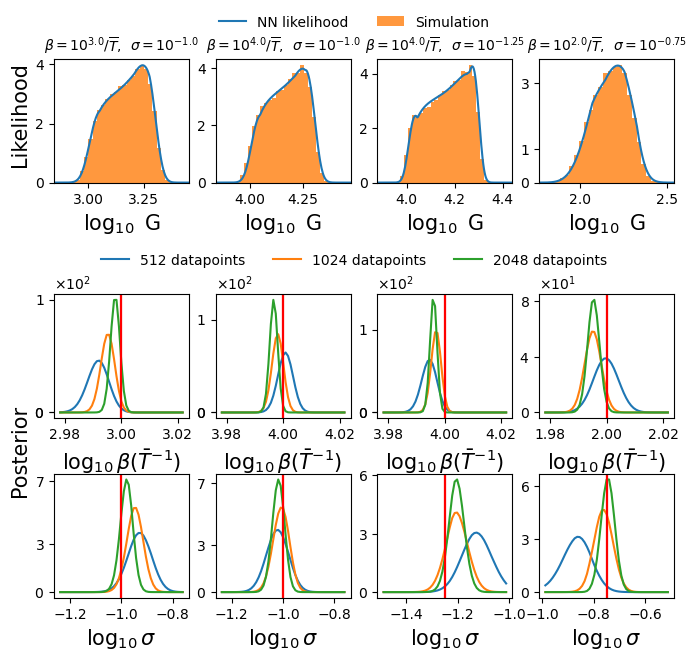

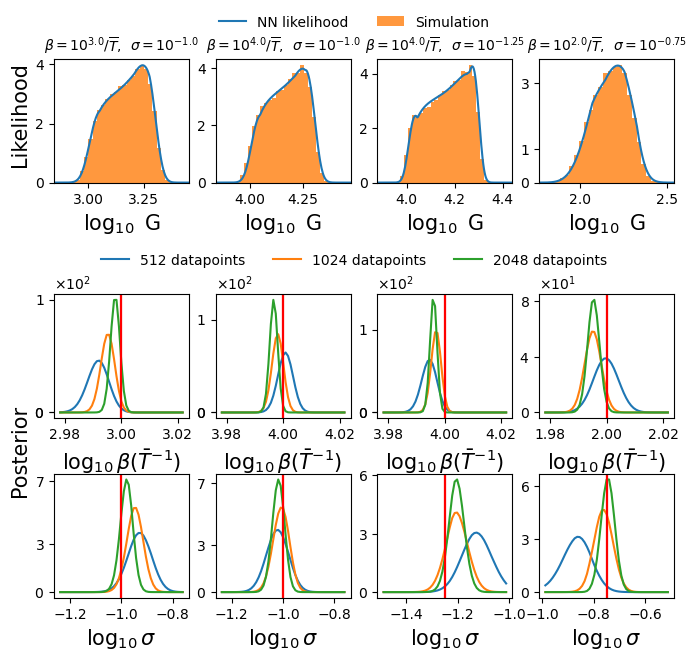

In [8]:
make_full_figure(model, target)